#NBO3 DATA ANALYSIS

## 1. Compare sector performance over time

The processed dataset contains financial ratios that allow comparison between companies of different sizes.

To understand how sectors differ in their growth strategies, I first calculate average values for each sector from 2018 to 2024.

The analysis focuses on three key measures:
- **R&D intensity:** investment in research and development relative to revenue.
- **Net margin:** profitability relative to revenue.
- **Free cash flow margin:** cash generated after capital expenditure relative to revenue.

These indicators provide an initial view of how different sectors invest, generate profits, and finance future growth.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/company_financials.csv")

df.groupby(["sector", "year"])[["rd_intensity", "net_margin", "fcf_margin"]].mean().round(3)

rd_intensity  net_margin  fcf_margin
sector     year                                      
Energy     2018         0.003       0.091       0.022
           2019         0.004       0.076      -0.003
           2020         0.005      -0.041      -0.014
           2021         0.002       0.112       0.066
           2022         0.002       0.123       0.035
           2023         0.002       0.103       0.033
           2024         0.002       0.111       0.055
Healthcare 2018         0.098       0.224       0.188
           2019         0.102       0.162       0.173
           2020         0.142       0.170       0.244
           2021         0.127       0.217       0.259
           2022         0.123       0.221       0.194
           2023         0.141       0.201       0.149
           2024         0.143       0.139       0.177
Technology 2018         0.094       0.268       0.273
           2019         0.152       0.259       0.271
           2020         0.142       0.278       0.301
           2021         0.126       0.329       0.295
           2022         0.156       0.252       0.235
           2023         0.114       0.367       0.335
           2024         0.098       0.387       0.333

## 2. Average measures for each sector 

To simplify the comparisons between sectors, I calculate the average values across the full 2018–2024 period.

This provides a summary comparison of each sector's:
- innovation investment,
- profitability,
- internal cash generation,
- capital investment requirements.

The results help identify the main growth and funding patterns that will be explored further.

In [27]:
sector_summary = df.groupby("sector")[[
    "rd_intensity",
    "net_margin",
    "fcf_margin",
    "capex_intensity"
]].mean().round(3)

sector_summary

,rd_intensity,net_margin,fcf_margin,capex_intensity
sector,,,,
Energy,0.003,0.082,0.028,0.187
Healthcare,0.128,0.190,0.200,0.042
Technology,0.128,0.308,0.293,0.077


## 3. Analyse differences in R&D investment

R&D intensity measures how much of a company's revenue is allocated to research and development.

A higher R&D intensity suggests that a sector relies more heavily on innovation and product development as part of its growth strategy.

The following chart compares the average R&D intensity across sectors to identify which industries invest more heavily in innovation relative to their revenue.

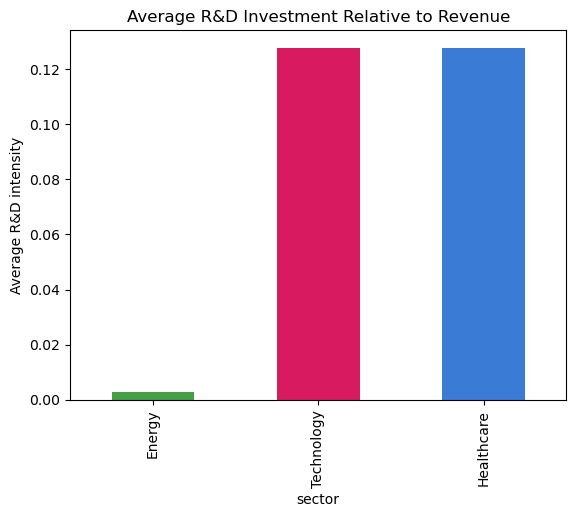

In [34]:
rd_sector = (
    df.groupby("sector")["rd_intensity"]
    .mean()
    .sort_values()
)
colors = {
    "Energy": "#43A047",
    "Healthcare": "#3A7BD5",
    "Technology": "#D81B60"
}
rd_sector.plot(
    kind="bar",
    ylabel="Average R&D intensity",
    title="Average R&D Investment Relative to Revenue",
    color=[colors[sector] for sector in rd_sector.index]
)
plt.show()

### Finding: Technology and Healthcare show the strongest R&D growth strategies

The comparison shows a clear difference in innovation investment between sectors.

Technology and Healthcare companies allocate a significantly larger proportion of revenue to R&D compared with Energy companies. This suggests that these sectors rely more heavily on innovation, research, and new product development to support future growth.

In contrast, Energy companies have much lower R&D intensity, indicating that their growth strategy is less dependent on research spending and more influenced by factors such as physical assets, production capacity, and market conditions.

This supports the idea that different industries follow different growth models: technology and healthcare are more innovation-driven, while energy is more capital and asset-driven.

In [ ]:
print("Net margin by company and year")
df.pivot_table(index="year", columns="name", values="net_margin").round(3)

Net margin by company and year


name,Apple,Chevron,Duke Energy,ExxonMobil,Johnson & Johnson,Microsoft,Nvidia,Pfizer,Stryker
year,,,,,,,,,
2018,0.224,0.089,0.112,0.072,0.188,0.312,NaN,NaN,0.261
2019,0.212,0.020,0.154,0.054,0.184,0.310,0.256,NaN,0.140
2020,0.209,-0.059,0.059,-0.124,0.178,0.365,0.260,0.220,0.111
2021,0.259,0.096,0.160,0.081,0.265,0.367,0.362,0.270,0.117
2022,0.253,0.144,0.089,0.135,0.224,0.341,0.162,0.310,0.128
2023,0.253,0.106,0.099,0.105,0.413,0.360,0.488,0.036,0.154
2024,0.240,0.087,0.151,0.096,0.158,0.361,0.558,0.126,0.132


In [ ]:
print("R&D intensity by company and year")
df.pivot_table(index="year", columns="name", values="rd_intensity").round(3)

R&D intensity by company and year


name,Apple,Chevron,ExxonMobil,Johnson & Johnson,Microsoft,Nvidia,Pfizer,Stryker
year,,,,,,,,
2018,0.054,0.003,0.004,0.132,0.134,NaN,NaN,0.063
2019,0.062,0.003,0.005,0.138,0.135,0.259,NaN,0.065
2020,0.068,0.005,0.006,0.147,0.123,0.235,0.209,0.069
2021,0.060,0.002,0.003,0.181,0.124,0.196,0.127,0.072
2022,0.067,0.001,0.002,0.177,0.128,0.272,0.113,0.079
2023,0.078,0.002,0.003,0.177,0.120,0.142,0.179,0.068
2024,0.080,0.002,0.003,0.194,0.115,0.099,0.170,0.065


In [ ]:
print("Nvidia: R&D spend vs revenue ($bn)")
df[df["name"] == "Nvidia"][["year", "rd_bn", "revenue_bn", "rd_intensity"]].round(2)

Nvidia: R&D spend vs revenue ($bn)


,year,rd_bn,revenue_bn,rd_intensity
56,2018,2.38,NaN,NaN
57,2019,2.83,10.92,0.26
58,2020,3.92,16.68,0.24
59,2021,5.27,26.91,0.20
60,2022,7.34,26.97,0.27
61,2023,8.68,60.92,0.14
62,2024,12.91,130.50,0.10


In [ ]:
print("Free cash flow margin by company and year")
df.pivot_table(index="year", columns="name", values="fcf_margin").round(3)

Free cash flow margin by company and year


name,Apple,Chevron,Duke Energy,ExxonMobil,Johnson & Johnson,Microsoft,Nvidia,Pfizer,Stryker
year,,,,,,,,,
2018,0.241,0.101,-0.093,0.057,0.227,0.304,NaN,NaN,0.150
2019,0.226,0.090,-0.120,0.020,0.243,0.316,NaN,NaN,0.104
2020,0.267,0.017,-0.045,-0.014,0.244,0.334,NaN,0.292,0.194
2021,0.254,0.130,-0.058,0.126,0.251,0.329,0.302,0.367,0.160
2022,0.283,0.153,-0.190,0.141,0.215,0.281,0.141,0.257,0.110
2023,0.260,0.098,-0.095,0.097,0.214,0.302,0.444,0.080,0.153
2024,0.278,0.074,0.002,0.088,0.223,0.254,0.466,0.155,0.154


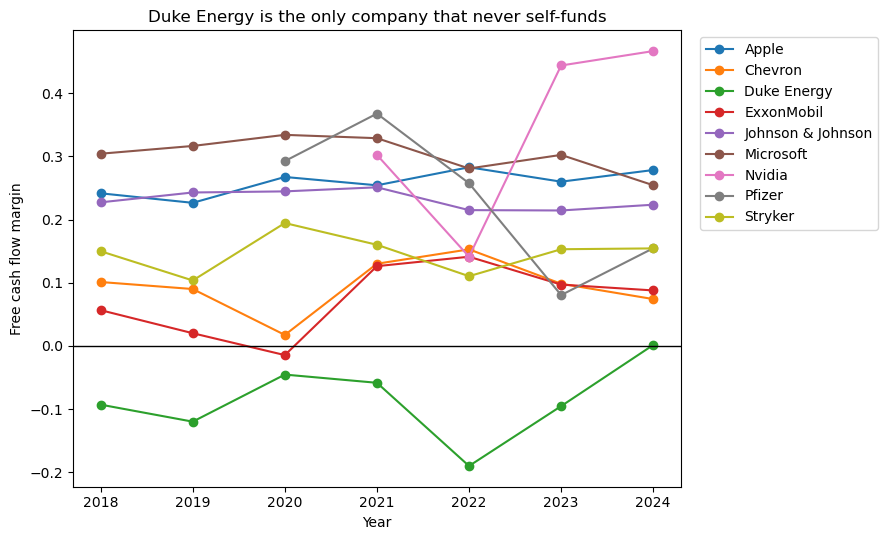

In [ ]:
# one column per company, one row per year
fcf = df.pivot(index="year", columns="name", values="fcf_margin")

fcf.plot(figsize=(9, 5.5), marker="o")

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Free cash flow margin")
plt.xlabel("Year")
plt.title("Duke Energy is the only company that never self-funds")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

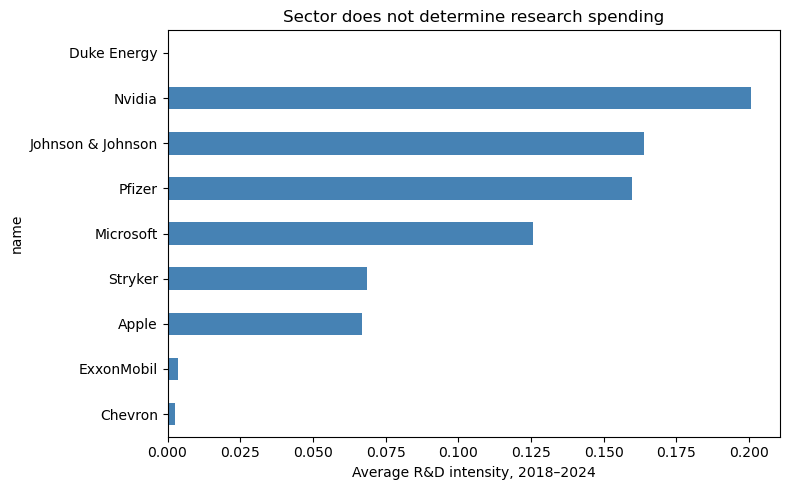

In [ ]:
avg = df.groupby("name")["rd_intensity"].mean().sort_values()

avg.plot(kind="barh", figsize=(8, 5), color="steelblue")

plt.xlabel("Average R&D intensity, 2018–2024")
plt.title("Sector does not determine research spending")
plt.tight_layout()
plt.show()

<Axes: ylabel='name'>

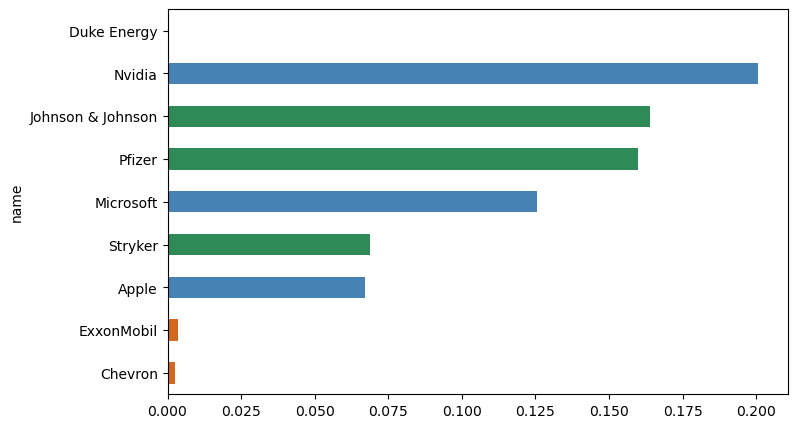

In [ ]:
sector_of = df.groupby("name")["sector"].first()
colour_map = {"Technology": "steelblue", "Healthcare": "seagreen", "Energy": "chocolate"}
bar_colours = sector_of[avg.index].map(colour_map)

avg.plot(kind="barh", figsize=(8, 5), color=bar_colours)

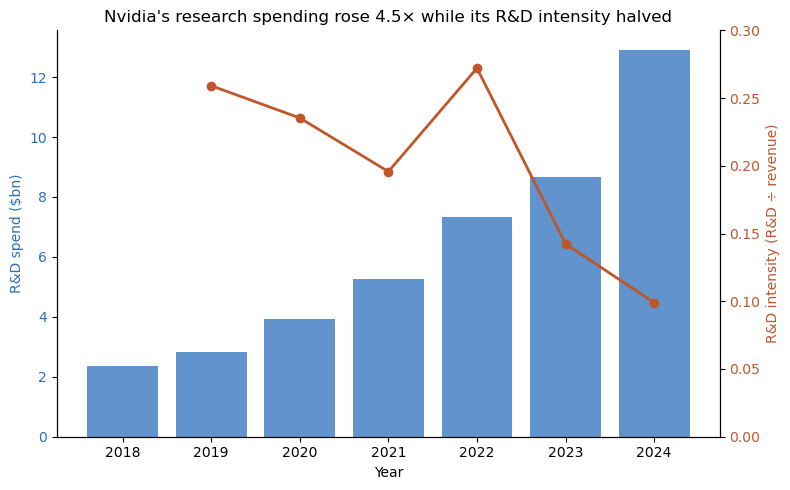

In [ ]:
nv = df[df["name"] == "Nvidia"].sort_values("year")

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(nv["year"], nv["rd_bn"], color="#2c6fbb", alpha=0.75, label="R&D spend ($bn)")
ax1.set_ylabel("R&D spend ($bn)", color="#2c6fbb")
ax1.tick_params(axis="y", labelcolor="#2c6fbb")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(nv["year"], nv["rd_intensity"], color="#c0562a",
         marker="o", linewidth=2, label="R&D intensity")
ax2.set_ylabel("R&D intensity (R&D ÷ revenue)", color="#c0562a")
ax2.tick_params(axis="y", labelcolor="#c0562a")
ax2.set_ylim(0, 0.3)

ax1.set_title("Nvidia's research spending rose 4.5× while its R&D intensity halved")
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

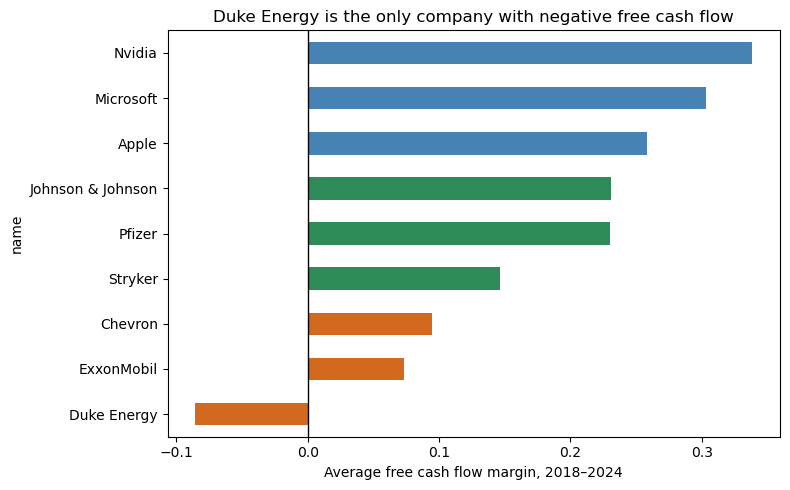

In [ ]:
fcf_avg = df.groupby("name")["fcf_margin"].mean().sort_values()

sector_of = df.groupby("name")["sector"].first()
colour_map = {"Technology": "steelblue", "Healthcare": "seagreen", "Energy": "chocolate"}
bar_colours = sector_of[fcf_avg.index].map(colour_map)

fcf_avg.plot(kind="barh", figsize=(8, 5), color=bar_colours)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Average free cash flow margin, 2018–2024")
plt.title("Duke Energy is the only company with negative free cash flow")
plt.tight_layout()
plt.show()